# Resultados — Organização e tratamento da base de qualidade da água (bacia do PCJ)

**Notebook autossuficiente e comentado**: todas as funções usadas estão definidas aqui mesmo (não depende de `src/`),
e cada linha de código traz um comentário explicando o que faz. Reproduz a **Figura 1** (faltantes por variável e
método), a **Tabela 1** (média/desvio antes × depois da imputação) e a comparação de **outliers** (IQR × ML).

> Rode de cima para baixo, a partir da **raiz do projeto** (onde está `data/interim/dados_organizados.csv`).

In [1]:
# =============================================================================
# (0) BIBLIOTECAS
# =============================================================================
%matplotlib inline
import re, warnings                              # re: expressões regulares (parser de números); warnings: silenciar avisos
warnings.filterwarnings("ignore")               # esconde avisos do sklearn (LOF etc.) para a saída ficar limpa
from dataclasses import dataclass, field         # para criar a estrutura PlanoImputacao de forma enxuta

import numpy as np                               # cálculos numéricos (vetores/matrizes)
import pandas as pd                              # tabelas (DataFrame) e leitura de CSV
import matplotlib.pyplot as plt                  # gráficos (Figura 1, outliers)
from matplotlib.patches import Patch             # "retângulos" coloridos para montar a legenda manual

from sklearn.preprocessing import StandardScaler # padronização z-score (média 0, desvio 1)
from sklearn.impute import KNNImputer            # imputação por vizinhos mais próximos (KNN)
from sklearn.decomposition import PCA            # redução para 2D (só para visualizar)
from sklearn.ensemble import IsolationForest     # detector de outliers (isola pontos anômalos)
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors  # LOF e busca de vizinhos (KNN por distância)
from sklearn.model_selection import KFold        # validação cruzada usada na calibração do contamination

## Definições reutilizadas do projeto

As células abaixo trazem, embutidas, as constantes e funções que originalmente vivem em `src/`. O comportamento
é idêntico ao do pipeline — a diferença é que aqui ficam à vista, comentadas.

In [2]:
# =============================================================================
# (1) CONSTANTES: variáveis, tipos, marcadores de ausência e limiares
# =============================================================================
# As 23 variáveis físico-químicas/bacteriológicas, na mesma ordem do CSV.
FEATURES = [
    "COR(ppm Pt Co)", "TURB.(FTU)", "pH", "ALC.(ppm CaCO3)", "AC.(ppm CaCO3)",
    "O.C.(ppm O2)", "DBO(ppm O2)", "O.D.(ppm O2)", "Cl-(ppm Cl-)", "DUR.(ppm CaCO3)",
    "Fe(ppm Fe)", "Mn(mg/l)", "N(ppm N)", "P(ppm P)", "Cond.(uS/cm)", "Amonia(mg/l)",
    "Surfact.(mg/l)", "Cianobacteria(cel/ml)", "S.T.(mg/l)", "C.T.(NMP/100ml)",
    "C.F.(NMP/100ml)", "CLOROFILA(ug/l)", "F(ppm F)",
]
# Tipo de cada coluna: Ano é inteiro; Mes/Calc são categorias; as variáveis são float (aceitam NaN).
DTYPES = {"Ano": "int64", "Mes": "category", "Calc": "category",
          **{c: "float64" for c in FEATURES}}
# Textos que o SEMAE usa para "sem medição" — viram NaN na leitura.
MISSING_MARKERS = ["--", "---", "-", ""]

# --- Limiares de imputação e detecção (originalmente em src/config.py) ---
RANDOM_STATE = 42              # semente fixa -> resultados reprodutíveis
MISSING_DROP_ABOVE = 0.30      # > 30% de faltantes  -> excluir a variável
MISSING_SIMPLE_BELOW = 0.05    # < 5% de faltantes   -> imputar por média/mediana
KNN_SCALE_ABOVE = 0.15         # > 15% de faltantes  -> padronizar antes do KNN
SKEW_THRESHOLD = 1.0           # |assimetria| > 1    -> usar mediana (em vez de média)
KNN_N_NEIGHBORS = 5            # k do KNN (nº de vizinhos)
KNN_WEIGHTS = "distance"       # vizinhos mais próximos pesam mais
CONTAMINATION = 0.07           # fração esperada de anomalias (usada pelos detectores de ML)

# --- Limites regulatórios CONAMA 357/2005, Classe 2: (mínimo, máximo); None = sem limite daquele lado ---
CONAMA_357_CLASSE2 = {
    "COR(ppm Pt Co)": (None, 75.0), "TURB.(FTU)": (None, 100.0), "pH": (6.0, 9.0),
    "DBO(ppm O2)": (None, 5.0), "O.D.(ppm O2)": (5.0, None), "Cl-(ppm Cl-)": (None, 250.0),
    "Fe(ppm Fe)": (None, 0.3), "Mn(mg/l)": (None, 0.1), "P(ppm P)": (None, 0.1),
    "Amonia(mg/l)": (None, 3.7), "Surfact.(mg/l)": (None, 0.5),
    "Cianobacteria(cel/ml)": (None, 50_000.0), "C.F.(NMP/100ml)": (None, 1_000.0),
    "CLOROFILA(ug/l)": (None, 30.0), "F(ppm F)": (None, 1.4),
}

In [3]:
# =============================================================================
# (2) CARGA DA BASE: parser de números em notação brasileira + tabela de modelagem
# =============================================================================
# Reconhece "30.000" (milhar) para não confundir com "30,000" (decimal).
_THOUSAND_PATTERN = re.compile(r"^\d{1,3}(\.\d{3})+$")

def _parse_br_number(value):
    """'3,23'->3.23 | '23.000'->23000 | '30.000,00'->30000 | '--'->NaN."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return float("nan")                       # já é vazio -> NaN
    s = str(value).strip()                        # vira texto e tira espaços das pontas
    if s in MISSING_MARKERS:                      # '--', '-', '' etc. -> NaN
        return float("nan")
    if "," in s:                                  # tem vírgula: ela é o decimal; pontos são milhar
        s = s.replace(".", "").replace(",", ".")  # remove milhar, troca vírgula por ponto
    elif _THOUSAND_PATTERN.match(s):              # só pontos no padrão ###.### -> milhar
        s = s.replace(".", "")
    try:
        return float(s)                           # tenta virar número
    except ValueError:
        return float("nan")                       # não deu -> NaN

def load_semae(path="data/interim/dados_organizados.csv"):
    """Lê o CSV consolidado e aplica tipagem + parser brasileiro (23 variáveis)."""
    df = pd.read_csv(path, encoding="utf-8", dtype=str, keep_default_na=False)  # lê tudo como texto
    for col in FEATURES:                          # garante que todas as 23 colunas existam
        if col not in df.columns:
            df[col] = ""
    df = df[["Ano", "Mes", "Calc"] + FEATURES]    # reordena: identificação + variáveis
    for col in FEATURES:                          # converte cada variável para número
        df[col] = df[col].map(_parse_br_number)
    return df.astype(DTYPES)                       # aplica os tipos finais (int/category/float)

def faltantes_por_variavel(df):
    """% de faltantes (0–1) por variável, do maior para o menor."""
    return df[FEATURES].isna().mean().sort_values(ascending=False)

# --- Tabela de modelagem: uma linha por mês (estatística Méd.) + índices temporais ---
_MES_NUM = {"Jan": 1, "Fev": 2, "Mar": 3, "Abr": 4, "Mai": 5, "Jun": 6,
            "Jul": 7, "Ago": 8, "Set": 9, "Out": 10, "Nov": 11, "Dez": 12}  # mês -> número
_MESES_UMIDOS = {10, 11, 12, 1, 2, 3}             # estação úmida (out–mar) no clima do PCJ

def tabela_modelagem(df, estatistica="Méd."):
    sub = df[(df["Calc"] == estatistica) & (df["Mes"] != "Ano")].copy()  # só a média mensal (exclui linhas de resumo "Ano")
    sub["mes_num"] = sub["Mes"].map(_MES_NUM).astype(int)                 # número do mês
    sub["data"] = pd.to_datetime(dict(year=sub["Ano"], month=sub["mes_num"], day=1))  # data (1º dia do mês)
    sub["trimestre"] = sub["data"].dt.quarter                            # trimestre (1–4)
    sub["estacao"] = np.where(sub["mes_num"].isin(_MESES_UMIDOS), "úmida", "seca")     # úmida/seca
    cols = ["data", "Ano", "Mes", "mes_num", "trimestre", "estacao"] + FEATURES        # ordem final das colunas
    return sub[cols].sort_values("data").reset_index(drop=True)          # ordena por data e renumera

In [4]:
# =============================================================================
# (3) REGRAS DE IMPUTAÇÃO (ADR-004): decidir -> planejar -> imputar -> validar
# =============================================================================
@dataclass
class PlanoImputacao:
    """Guarda quais variáveis excluir / imputar por média / mediana / KNN."""
    excluir: list = field(default_factory=list)
    media: list = field(default_factory=list)
    mediana: list = field(default_factory=list)
    knn: list = field(default_factory=list)
    resumo: pd.DataFrame = field(default_factory=pd.DataFrame)
    @property
    def manter(self):
        return self.media + self.mediana + self.knn   # todas as mantidas (tudo menos as excluídas)

def _decidir(frac_nan, skew):
    """Aplica a árvore de decisão a UMA variável (fração de NaN + assimetria)."""
    if frac_nan > MISSING_DROP_ABOVE:                 # > 30% -> fora
        return "EXCLUIR"
    if frac_nan < MISSING_SIMPLE_BELOW:               # < 5% -> univariada simples
        if pd.notna(skew) and abs(skew) > SKEW_THRESHOLD:
            return "Mediana"                          # assimétrica -> mediana
        return "Média"                                # simétrica -> média
    return "KNN"                                      # 5–30% -> KNN

def resumo_faltantes(df, features):
    """Monta a tabela variavel × (% NaN, assimetria, decisão)."""
    pct = df[features].isna().mean() * 100            # % de faltantes por variável
    skew = df[features].skew(numeric_only=True)       # assimetria por variável
    linhas = []
    for col in features:                              # decide variável por variável
        sk = skew.get(col, np.nan)
        linhas.append({"variavel": col, "pct_nan": round(float(pct[col]), 2),
                       "skew": round(float(sk), 2) if pd.notna(sk) else np.nan,
                       "decisao": _decidir(pct[col] / 100, sk)})
    return pd.DataFrame(linhas).sort_values("pct_nan", ascending=False).reset_index(drop=True)

def planejar_imputacao(df, features):
    """Classifica cada variável nas listas do PlanoImputacao."""
    resumo = resumo_faltantes(df, features)
    plano = PlanoImputacao(resumo=resumo)
    mapa = {"EXCLUIR": plano.excluir, "Média": plano.media,
            "Mediana": plano.mediana, "KNN": plano.knn}
    for _, row in resumo.iterrows():                  # joga cada variável na lista da sua decisão
        mapa[row["decisao"]].append(row["variavel"])
    return plano

def imputar(df, features, plano=None):
    """Preenche os faltantes conforme o plano e devolve (base_imputada, plano)."""
    if plano is None:
        plano = planejar_imputacao(df, features)
    out = df.copy()
    for col in plano.media:                           # média nas variáveis simétricas <5%
        out[col] = out[col].fillna(out[col].mean())
    for col in plano.mediana:                         # mediana nas assimétricas <5%
        out[col] = out[col].fillna(out[col].median())
    if plano.knn:                                     # KNN nas variáveis de 5–30%
        base = plano.media + plano.mediana + plano.knn  # usa todas as mantidas como vizinhança
        bloco = out[base].to_numpy(dtype=float)
        scaler = None
        if out[plano.knn].isna().mean().max() > KNN_SCALE_ABOVE:  # se algum alvo tem >15% NaN, padroniza
            scaler = StandardScaler(); bloco = scaler.fit_transform(bloco)
        bloco = KNNImputer(n_neighbors=KNN_N_NEIGHBORS, weights=KNN_WEIGHTS).fit_transform(bloco)  # imputa
        if scaler is not None:
            bloco = scaler.inverse_transform(bloco)   # desfaz a padronização
        out[base] = bloco
    return out.drop(columns=plano.excluir, errors="ignore"), plano       # remove as excluídas

def _delta_pct(a, b):
    """Variação percentual de a para b (para a Tabela 1)."""
    if a == 0 or pd.isna(a):
        return np.nan
    return round((b - a) / abs(a) * 100, 2)

def validar_imputacao(antes, depois, features):
    """Compara média e desvio antes × depois; variações pequenas = distribuição preservada."""
    cols = [c for c in features if c in depois.columns]
    linhas = []
    for col in cols:
        a, d = antes[col], depois[col]
        linhas.append({"variavel": col, "media_antes": a.mean(), "media_depois": d.mean(),
                       "std_antes": a.std(), "std_depois": d.std(),
                       "delta_media_%": _delta_pct(a.mean(), d.mean()),
                       "delta_std_%": _delta_pct(a.std(), d.std())})
    return pd.DataFrame(linhas).round(3)

In [5]:
# =============================================================================
# (4) CALIBRAÇÃO DO contamination (estabilidade por Jaccard em validação cruzada)
# =============================================================================
def jaccard(a, b):
    """Sobreposição entre dois conjuntos de flags: interseção / união (1 = idênticos)."""
    a, b = np.asarray(a, bool), np.asarray(b, bool)
    u = (a | b).sum()
    return float((a & b).sum() / u) if u else 1.0

def calibrar_contamination(X, grid=(0.05, 0.06, 0.07, 0.08, 0.09, 0.10),
                           cv=5, random_state=RANDOM_STATE):
    """Para cada contamination, mede quão ESTÁVEL é a detecção entre folds (Jaccard)."""
    kf = KFold(n_splits=cv, shuffle=True, random_state=random_state)     # divide os dados em 5 folds
    linhas = []
    for c in grid:                                                       # testa cada valor de contamination
        full = IsolationForest(contamination=c, n_estimators=200,
                               random_state=random_state).fit_predict(X) == -1   # flags na base inteira
        fold = []
        for tr, _ in kf.split(X):                                        # reajusta em cada fold de treino
            m = IsolationForest(contamination=c, n_estimators=200,
                                random_state=random_state).fit(X[tr])
            fold.append(m.predict(X) == -1)                              # prediz a base toda
        js = [jaccard(fold[i], fold[j]) for i in range(len(fold)) for j in range(i + 1, len(fold))]  # concordância par a par
        linhas.append({"contamination": c, "n_flags": int(full.sum()),
                       "taxa": round(float(full.mean()), 4),
                       "estabilidade_jaccard": round(float(np.mean(js)), 4) if js else float("nan")})
    return pd.DataFrame(linhas).sort_values("estabilidade_jaccard", ascending=False).reset_index(drop=True)  # mais estável primeiro

In [6]:
# =============================================================================
# (5) CARGA E TABELA DE MODELAGEM (média mensal, 192 meses)
# =============================================================================
df = load_semae()                               # lê data/interim/dados_organizados.csv (parser BR)
mod = tabela_modelagem(df, estatistica="Méd.")  # 1 linha por mês, com data e índices sazonais
print("Tabela de modelagem:", mod.shape, "(linhas × colunas)")  # esperado: (192, 29)
mod.head()                                      # espia as primeiras linhas

Tabela de modelagem: (192, 29) (linhas × colunas)


,data,Ano,Mes,mes_num,trimestre,estacao,COR(ppm Pt Co),TURB.(FTU),pH,ALC.(ppm CaCO3),...,P(ppm P),Cond.(uS/cm),Amonia(mg/l),Surfact.(mg/l),Cianobacteria(cel/ml),S.T.(mg/l),C.T.(NMP/100ml),C.F.(NMP/100ml),CLOROFILA(ug/l),F(ppm F)
0,2009-01-01,2009,Jan,1,1,úmida,432.0,131.0,7.2,34.0,...,NaN,145.0,NaN,NaN,6850.0,NaN,50000.0,23000.0,11.35,0.16
1,2009-02-01,2009,Fev,2,1,úmida,868.0,238.0,7.1,31.0,...,NaN,133.0,NaN,NaN,2100.0,NaN,240000.0,30000.0,7.81,0.16
2,2009-03-01,2009,Mar,3,1,úmida,158.0,63.0,7.4,46.0,...,NaN,171.0,NaN,NaN,1798.0,NaN,500000.0,170000.0,7.62,0.16
3,2009-04-01,2009,Abr,4,2,seca,63.0,36.0,7.4,47.0,...,NaN,201.0,NaN,NaN,6920.0,NaN,150000.0,17000.0,9.93,0.16
4,2009-05-01,2009,Mai,5,2,seca,33.0,14.0,7.3,57.0,...,NaN,292.0,NaN,NaN,7605.0,NaN,23500.0,4550.0,18.97,0.16


## 1. Dados faltantes e plano de imputação

Regra (ADR-004): **> 30%** → excluir; **5–30%** → KNN (k = 5, pesos por distância, padroniza se > 15%);
**< 5%** → média (simétrica) ou mediana (|skew| > 1).

In [7]:
# --- Aplica a árvore de decisão a cada variável ---
plano = planejar_imputacao(mod, FEATURES)                    # decide excluir/média/mediana/KNN
print("Excluídas (>30%):", plano.excluir)                    # 7 variáveis
print("KNN (5-30%):", plano.knn)
print("Média:", plano.media, "| Mediana:", plano.mediana)
print(f"→ {len(plano.manter)} variáveis mantidas de {len(FEATURES)}")  # 16 de 23
plano.resumo                                                 # tabela completa (% NaN, skew, decisão)

Excluídas (>30%): ['S.T.(mg/l)', 'Surfact.(mg/l)', 'DBO(ppm O2)', 'P(ppm P)', 'N(ppm N)', 'Amonia(mg/l)', 'C.T.(NMP/100ml)']
KNN (5-30%): ['C.F.(NMP/100ml)', 'F(ppm F)', 'CLOROFILA(ug/l)', 'Cianobacteria(cel/ml)', 'AC.(ppm CaCO3)', 'ALC.(ppm CaCO3)']
Média: ['O.D.(ppm O2)', 'pH'] | Mediana: ['DUR.(ppm CaCO3)', 'O.C.(ppm O2)', 'Fe(ppm Fe)', 'Mn(mg/l)', 'Cl-(ppm Cl-)', 'Cond.(uS/cm)', 'TURB.(FTU)', 'COR(ppm Pt Co)']
→ 16 variáveis mantidas de 23


,variavel,pct_nan,skew,decisao
0,S.T.(mg/l),99.48,NaN,EXCLUIR
1,Surfact.(mg/l),99.48,NaN,EXCLUIR
2,DBO(ppm O2),96.35,2.64,EXCLUIR
3,P(ppm P),90.62,0.45,EXCLUIR
4,N(ppm N),89.06,3.83,EXCLUIR
5,Amonia(mg/l),75.52,0.23,EXCLUIR
6,C.T.(NMP/100ml),60.94,3.27,EXCLUIR
7,C.F.(NMP/100ml),19.79,3.77,KNN
8,F(ppm F),18.75,0.63,KNN
9,CLOROFILA(ug/l),7.81,6.11,KNN


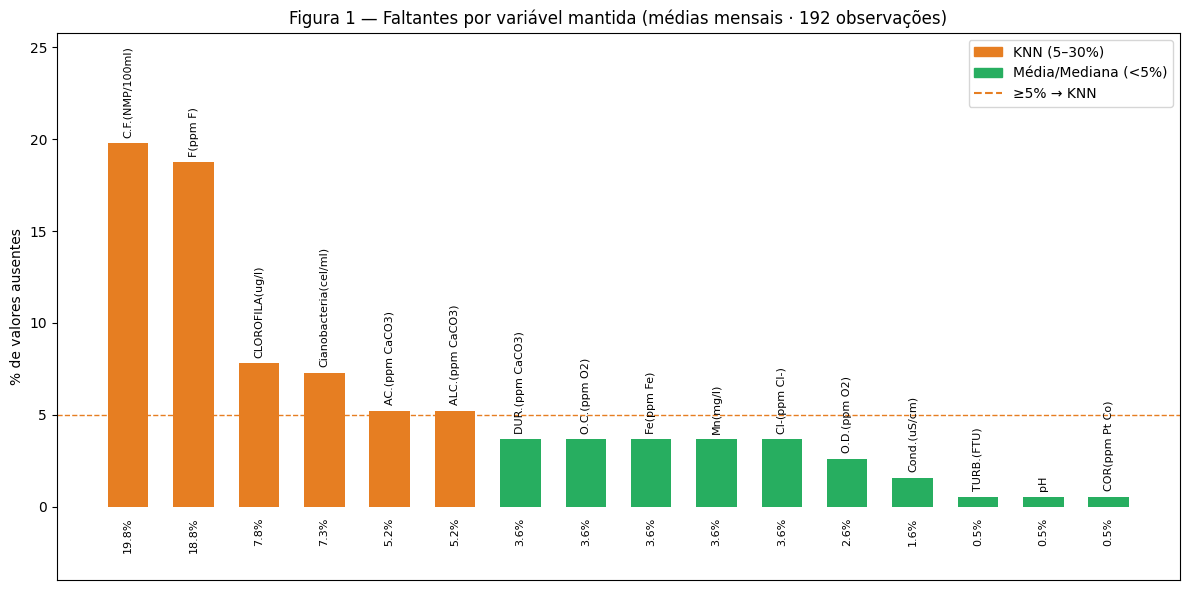

In [8]:
# =============================================================================
# FIGURA 1 — % de ausentes por variável MANTIDA, colorida pelo método
# =============================================================================
resumo = plano.resumo                                        # tabela de decisões
mant = resumo[resumo["decisao"] != "EXCLUIR"].reset_index(drop=True)  # só as mantidas
COR = {"KNN": "#e67e22", "Média": "#27ae60", "Mediana": "#27ae60"}    # laranja=KNN, verde=média/mediana

fig, ax = plt.subplots(figsize=(12, 6))                      # área do gráfico
ax.bar(range(len(mant)), mant["pct_nan"], color=[COR[d] for d in mant["decisao"]], width=0.62)  # barras
ax.axhline(MISSING_SIMPLE_BELOW * 100, ls="--", color="#e67e22", lw=1)  # linha de corte 5% -> KNN
for i, (v, p) in enumerate(zip(mant["variavel"], mant["pct_nan"])):     # rótulos em cada barra
    ax.text(i, p + 0.3, v, rotation=90, ha="center", va="bottom", fontsize=8)   # nome ACIMA
    ax.text(i, -0.6, f"{p:.1f}%", rotation=90, ha="center", va="top", fontsize=8)  # % ABAIXO
ax.set_xticks([]); ax.set_ylim(-4, float(mant["pct_nan"].max()) + 6)   # sem ticks no X; folga no Y
ax.set_ylabel("% de valores ausentes")
ax.set_title("Figura 1 — Faltantes por variável mantida (médias mensais · 192 observações)")
ax.legend(handles=[Patch(color="#e67e22", label="KNN (5–30%)"),        # legenda manual
                   Patch(color="#27ae60", label="Média/Mediana (<5%)"),
                   plt.Line2D([0], [0], ls="--", color="#e67e22", label="≥5% → KNN")], loc="upper right")
plt.tight_layout()
plt.savefig("reports/figures/resultados_faltantes.png", dpi=150, bbox_inches="tight")  # salva a figura
plt.show()

## 2. Imputação e validação — Tabela 1 (antes × depois)

Variações pequenas de média e desvio indicam que a imputação **não distorceu** as distribuições.

In [9]:
imp, plano = imputar(mod, FEATURES, plano=plano)             # executa a imputação (base com 16 variáveis)
val = validar_imputacao(mod, imp, plano.manter)              # compara estatísticas antes × depois
tabela1 = val[["variavel", "media_antes", "media_depois",    # seleciona as colunas da Tabela 1
               "std_antes", "std_depois", "delta_media_%", "delta_std_%"]].round(3)
print("Maior variação absoluta — média: %.2f%% | desvio: %.2f%%"     # maiores desvios observados
      % (val["delta_media_%"].abs().max(), val["delta_std_%"].abs().max()))
tabela1

Maior variação absoluta — média: 6.39% | desvio: 8.87%


,variavel,media_antes,media_depois,std_antes,std_depois,delta_media_%,delta_std_%
0,O.D.(ppm O2),3.119,3.119,0.886,0.874,0.00,-1.32
1,pH,7.325,7.325,0.181,0.180,0.00,-0.26
2,DUR.(ppm CaCO3),53.973,53.828,17.627,17.317,-0.27,-1.76
3,O.C.(ppm O2),8.540,8.528,2.896,2.844,-0.15,-1.82
4,Fe(ppm Fe),2.154,2.127,1.957,1.926,-1.28,-1.58
5,Mn(mg/l),0.190,0.189,0.121,0.119,-0.77,-1.65
6,Cl-(ppm Cl-),44.692,44.484,26.747,26.274,-0.46,-1.77
7,Cond.(uS/cm),327.450,326.880,159.263,158.072,-0.17,-0.75
8,TURB.(FTU),63.576,63.391,76.455,76.298,-0.29,-0.21
9,COR(ppm Pt Co),120.476,120.250,110.341,110.096,-0.19,-0.22


## 3. Detecção de outliers — IQR (tradicional) × ML (multivariado)

,método,n_marcados,taxa_%
0,IQR (univariado),91,47.4
1,IsolationForest,13,6.8
2,LOF,13,6.8
3,KNN,13,6.8


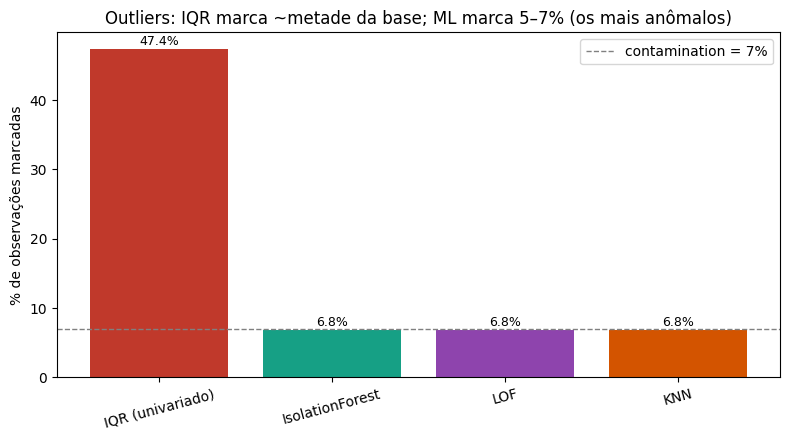

In [10]:
# =============================================================================
# Outliers: IQR (univariado) vs IForest/LOF/KNN (multivariados)
# =============================================================================
X_uni = mod[FEATURES]                                        # todas as variáveis (para o IQR)
n = len(mod)                                                 # nº de meses (192)
q1, q3 = X_uni.quantile(.25), X_uni.quantile(.75); iqr = q3 - q1     # quartis e amplitude interquartil
iqr_flag = ((X_uni.lt(q1 - 1.5 * iqr)) | (X_uni.gt(q3 + 1.5 * iqr))).fillna(False).any(axis=1).to_numpy()
# ^ marca o mês se QUALQUER variável cair fora das cercas de Tukey (Q1-1.5·IQR, Q3+1.5·IQR)

falt = faltantes_por_variavel(mod)                           # % de faltantes por variável
feats_multi = [c for c in FEATURES if falt[c] <= 0.05]       # multivariados só usam variáveis com <=5% NaN
Xm = mod[feats_multi]; complete = Xm.notna().all(axis=1).to_numpy()   # meses completos nessas variáveis
Xs = StandardScaler().fit_transform(Xm.loc[complete].to_numpy())      # padroniza (necessário p/ distâncias)
C = CONTAMINATION                                            # fração-alvo de anomalias (0,07)

iforest = IsolationForest(contamination=C, n_estimators=200, random_state=RANDOM_STATE).fit_predict(Xs) == -1
lof = LocalOutlierFactor(contamination=C).fit_predict(Xs) == -1        # -1 = outlier
k = min(KNN_N_NEIGHBORS, Xs.shape[0] - 1)                    # nº de vizinhos para o KNN
dist, _ = NearestNeighbors(n_neighbors=k).fit(Xs).kneighbors(Xs)      # distâncias aos vizinhos
knn = dist[:, -1] > np.quantile(dist[:, -1], 1 - C)          # marca os 7% mais distantes do k-ésimo vizinho

def _para_total(mask_sub):                                   # devolve a flag ao espaço dos 192 meses
    v = np.zeros(n, bool); v[complete] = mask_sub; return v

flags = {"IQR (univariado)": iqr_flag, "IsolationForest": _para_total(iforest),
         "LOF": _para_total(lof), "KNN": _para_total(knn)}
comp = pd.DataFrame({"método": list(flags),                  # tabela: método, nº e % marcados
                     "n_marcados": [int(m.sum()) for m in flags.values()],
                     "taxa_%": [round(100 * m.mean(), 1) for m in flags.values()]})
display(comp)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(comp["método"], comp["taxa_%"], color=["#c0392b", "#16a085", "#8e44ad", "#d35400"])  # barras por método
ax.axhline(C * 100, ls="--", color="gray", lw=1, label=f"contamination = {C:.0%}")          # taxa-alvo 7%
for i, t in enumerate(comp["taxa_%"]):                       # escreve a % em cima de cada barra
    ax.text(i, t + 0.6, f"{t:.1f}%", ha="center", fontsize=9)
ax.set_ylabel("% de observações marcadas")
ax.set_title("Outliers: IQR marca ~metade da base; ML marca 5–7% (os mais anômalos)")
ax.legend(); plt.xticks(rotation=15); plt.tight_layout()
plt.savefig("reports/figures/resultados_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

### Comparação visual — quais pontos cada método marca

O gráfico acima mostra **quantos**; aqui, **quais**. Mesmo mapa PCA; em vermelho, os marcados por cada método.
O IQR estoura até pontos no miolo denso (basta uma variável fora de Tukey); os de ML concentram os ~7% nas bordas.

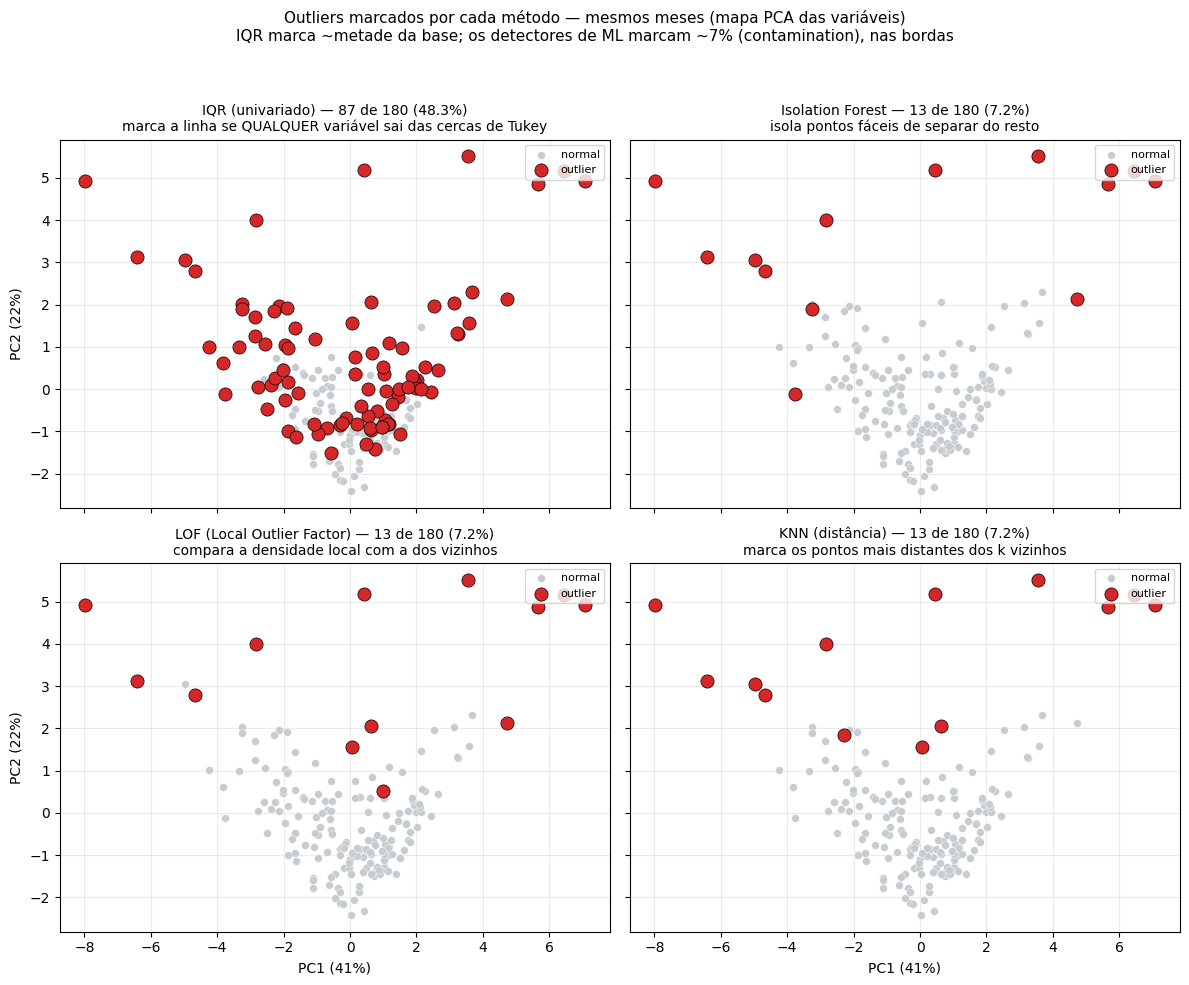

In [11]:
# =============================================================================
# Figura por método: quais pontos cada um marca (mesmo mapa PCA)
# =============================================================================
Z = PCA(n_components=2, random_state=0).fit_transform(Xs)    # projeta os meses completos em 2D (só p/ desenhar)
var = PCA(n_components=2, random_state=0).fit(Xs).explained_variance_ratio_ * 100  # % de variância de PC1/PC2
iqr_map = iqr_flag[complete]                                 # IQR restrito aos meses do mapa
Nc = Xs.shape[0]                                             # nº de meses no mapa

paineis = [("IQR (univariado)", iqr_map, "marca a linha se QUALQUER variável sai das cercas de Tukey"),
           ("Isolation Forest", iforest, "isola pontos fáceis de separar do resto"),
           ("LOF (Local Outlier Factor)", lof, "compara a densidade local com a dos vizinhos"),
           ("KNN (distância)", knn, "marca os pontos mais distantes dos k vizinhos")]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)   # grade 2×2
for ax, (nome, flag, desc) in zip(axes.ravel(), paineis):   # um painel por método
    flag = np.asarray(flag)
    ax.scatter(Z[~flag, 0], Z[~flag, 1], s=32, color="#c7ccd1", edgecolor="white",   # cinza = normal
               linewidth=0.3, label="normal", zorder=2)
    ax.scatter(Z[flag, 0], Z[flag, 1], s=90, color="#d62728", edgecolor="black",     # vermelho = outlier
               linewidth=0.5, label="outlier", zorder=3)
    ax.set_title(f"{nome} — {int(flag.sum())} de {Nc} ({100 * flag.mean():.1f}%)\n{desc}", fontsize=10)
    ax.grid(alpha=.25); ax.legend(fontsize=8, loc="upper right")
for ax in axes[1, :]:                                        # rótulos do eixo X só na linha de baixo
    ax.set_xlabel(f"PC1 ({var[0]:.0f}%)")
for ax in axes[:, 0]:                                        # rótulos do eixo Y só na coluna da esquerda
    ax.set_ylabel(f"PC2 ({var[1]:.0f}%)")
fig.suptitle("Outliers marcados por cada método — mesmos meses (mapa PCA das variáveis)\n"
             "IQR marca ~metade da base; os detectores de ML marcam ~7% (contamination), nas bordas",
             fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("reports/figures/resultados_metodos_outliers.png", dpi=170, bbox_inches="tight")
plt.show()

In [12]:
# --- Calibração do contamination: qual valor é mais estável? ---
cal = calibrar_contamination(Xs)                             # roda a validação cruzada para cada contamination
display(cal)                                                 # tabela ordenada por estabilidade (Jaccard)
print(f"Maior estabilidade em contamination = {cal.iloc[0]['contamination']:.2f}. "
      f"O projeto adotou {CONTAMINATION:.2f} — vale justificar a escolha no texto.")

,contamination,n_flags,taxa,estabilidade_jaccard
0,0.08,15,0.0833,0.8180
1,0.07,13,0.0722,0.8081
2,0.06,11,0.0611,0.7997
3,0.09,17,0.0944,0.7720
4,0.10,18,0.1000,0.7705
5,0.05,9,0.0500,0.7702


Maior estabilidade em contamination = 0.08. O projeto adotou 0.07 — vale justificar a escolha no texto.


## 4. Referência regulatória — CONAMA 357/2005, Classe 2

In [13]:
# --- Limites legais usados como referência (do schema do projeto) ---
conama = pd.DataFrame([(v, lo, hi) for v, (lo, hi) in CONAMA_357_CLASSE2.items()],   # dict -> tabela
                      columns=["variável", "limite_mín", "limite_máx"])
display(conama)
print("Resumo: 16 de 23 variáveis mantidas; imputação combinada (média/mediana + KNN) "
      "sem distorcer as distribuições (Tabela 1).")

,variável,limite_mín,limite_máx
0,COR(ppm Pt Co),NaN,75.0
1,TURB.(FTU),NaN,100.0
2,pH,6.0,9.0
3,DBO(ppm O2),NaN,5.0
4,O.D.(ppm O2),5.0,NaN
5,Cl-(ppm Cl-),NaN,250.0
6,Fe(ppm Fe),NaN,0.3
7,Mn(mg/l),NaN,0.1
8,P(ppm P),NaN,0.1
9,Amonia(mg/l),NaN,3.7


Resumo: 16 de 23 variáveis mantidas; imputação combinada (média/mediana + KNN) sem distorcer as distribuições (Tabela 1).
